# Restaurant Clustering

Builds the clustering outputs used by the dashboard:
- `data_output/reviews.csv`: review-level text corpus with cluster labels
- `data_output/clustering_results.csv`: restaurant-level cluster assignments with 2D coordinates


In [87]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from umap import UMAP
import scipy.sparse as sp

from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction import text

BASE_DIR = Path("..")
KOL_PATH = BASE_DIR / "data" / "kol" / "KOL_Posts.csv"
PLACES_PATH = BASE_DIR / "_1_eda" / "data_output" / "places_api_new_results.csv"
REVIEWS_PATH = BASE_DIR / "_3_marketing" / "data_output" / "restaurant_reviews.parquet"
OUTPUT_DIR = Path("data_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GMV_VIEW = BASE_DIR / "_5_GA_data" / "data_output" / "gmv" / "gmv_view.parquet" # New clustering to be based on this GMV data

kol_posts = pd.read_csv(KOL_PATH) # KOL posts
places = pd.read_csv(PLACES_PATH) # Places API results
restaurant_reviews = pd.read_parquet(REVIEWS_PATH) # Restaurant reviews
gmv_view = pd.read_parquet(GMV_VIEW) # GMV data

kol_posts # 923 rows × 35 columns
places # 2392 rows × 12 columns
restaurant_reviews # 9674 rows × 15 columns
gmv_view # 17319 rows × 16 columns

restaurant_reviews

,input_restaurant_name,pulled_at_utc,source,place_id,matched_name,review_id,author_name,author_url,profile_photo_url,rating,language,review_text,relative_time_description,review_time_unix,review_time_utc
0,Melody Bangkok,2026-02-16T15:06:12.727968+00:00,google_places,ChIJ-6r24ICf4jARC6jtWZYj7S8,Melody Bangkok,ChIJ-6r24ICf4jARC6jtWZYj7S8_1770211654_NATTAWA...,NATTAWAT RATTANAPONGPRAKIT,https://www.google.com/maps/contrib/1024293807...,https://lh3.googleusercontent.com/a-/ALV-UjVOX...,5,en-US,We ate it all before I could take a picture! T...,a week ago,1770211654,2026-02-04T13:27:34+00:00
1,Melody Bangkok,2026-02-16T15:06:12.727968+00:00,google_places,ChIJ-6r24ICf4jARC6jtWZYj7S8,Melody Bangkok,ChIJ-6r24ICf4jARC6jtWZYj7S8_1770021873_Mizutan...,Mizutani Koichi,https://www.google.com/maps/contrib/1102947333...,https://lh3.googleusercontent.com/a-/ALV-UjU8O...,1,en-US,The Happy Hour menu does not include draft bee...,2 weeks ago,1770021873,2026-02-02T08:44:33+00:00
2,Melody Bangkok,2026-02-16T15:06:12.727968+00:00,google_places,ChIJ-6r24ICf4jARC6jtWZYj7S8,Melody Bangkok,ChIJ-6r24ICf4jARC6jtWZYj7S8_1769797681_Patpoom...,Patpoom MSoulScent,https://www.google.com/maps/contrib/1168736595...,https://lh3.googleusercontent.com/a-/ALV-UjVEH...,5,en-US,"The staff are nice, friendly, and polite.\nThe...",2 weeks ago,1769797681,2026-01-30T18:28:01+00:00
3,Melody Bangkok,2026-02-16T15:06:12.727968+00:00,google_places,ChIJ-6r24ICf4jARC6jtWZYj7S8,Melody Bangkok,ChIJ-6r24ICf4jARC6jtWZYj7S8_1769692334_Jesada ...,Jesada Bobpahow,https://www.google.com/maps/contrib/1041664502...,https://lh3.googleusercontent.com/a-/ALV-UjVw9...,5,en-US,"Delicious food, great atmosphere.",2 weeks ago,1769692334,2026-01-29T13:12:14+00:00
4,Melody Bangkok,2026-02-16T15:06:12.727968+00:00,google_places,ChIJ-6r24ICf4jARC6jtWZYj7S8,Melody Bangkok,ChIJ-6r24ICf4jARC6jtWZYj7S8_1769692169_อรทัย ห...,อรทัย หลงทัพไทย,https://www.google.com/maps/contrib/1091362972...,https://lh3.googleusercontent.com/a/ACg8ocLqF_...,5,en-US,"The taste is good, the food is delicious.",2 weeks ago,1769692169,2026-01-29T13:09:29+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9669,Okuna Sushi Jungceylon (Phuket),2026-02-16T15:09:11.636531+00:00,google_places,ChIJQdyb6xg7UDARIxK_es9pIF4,Okuna Sushi Jungceylon (Phuket),ChIJQdyb6xg7UDARIxK_es9pIF4_1771235001_Jy S,Jy S,https://www.google.com/maps/contrib/1038710619...,https://lh3.googleusercontent.com/a-/ALV-UjVs6...,1,en-US,Three people went and ordered a variety of dis...,in the last week,1771235001,2026-02-16T09:43:21+00:00
9670,Okuna Sushi Jungceylon (Phuket),2026-02-16T15:09:11.636531+00:00,google_places,ChIJQdyb6xg7UDARIxK_es9pIF4,Okuna Sushi Jungceylon (Phuket),ChIJQdyb6xg7UDARIxK_es9pIF4_1770991294_Ni. Sha.,Ni. Sha.,https://www.google.com/maps/contrib/1030438452...,https://lh3.googleusercontent.com/a/ACg8ocIpyO...,1,en-US,Absolutely terrible! Warm sushi! Not recommended.,in the last week,1770991294,2026-02-13T14:01:34+00:00
9671,Okuna Sushi Jungceylon (Phuket),2026-02-16T15:09:11.636531+00:00,google_places,ChIJQdyb6xg7UDARIxK_es9pIF4,Okuna Sushi Jungceylon (Phuket),ChIJQdyb6xg7UDARIxK_es9pIF4_1770108077_Serap C...,Serap Civan,https://www.google.com/maps/contrib/1021855615...,https://lh3.googleusercontent.com/a/ACg8ocK57D...,5,NaN,,a week ago,1770108077,2026-02-03T08:41:17+00:00
9672,Okuna Sushi Jungceylon (Phuket),2026-02-16T15:09:11.636531+00:00,google_places,ChIJQdyb6xg7UDARIxK_es9pIF4,Okuna Sushi Jungceylon (Phuket),ChIJQdyb6xg7UDARIxK_es9pIF4_1769696963_Gökhan ...,Gökhan KILIÇ,https://www.google.com/maps/contrib/1066853741...,https://lh3.googleusercontent.com/a-/ALV-UjXjK...,4,NaN,,2 weeks ago,1769696963,2026-01-29T14:29:23+00:00


## 1. Build the Restaurant Text Corpus


In [88]:
# 1. Aggregate KOL content with ID
kol_aggregated = (
    kol_posts.groupby(["Restaurant Code", "Restaurant Name"])["Content"]
    .apply(lambda s: " ".join(s.dropna().astype(str)))
    .reset_index()
    .rename(columns={"Restaurant Name": "restaurant name", "Content": "kol_text", "Restaurant Code": "restaurant_id"})
)

# 2. Prepare Google Places data with ID
place_text = (
    places[["input_string", "raw_types", "Cuisine", "city", "country"]]
    .rename(columns={"input_string": "restaurant name"})
    .drop_duplicates(["restaurant name"])
)

# 3. Aggregate Reviews with ID
review_text = (
    restaurant_reviews.groupby(["input_restaurant_name"])["review_text"]
    .apply(lambda s: " ".join(s.dropna().astype(str)))
    .reset_index()
    .rename(columns={"input_restaurant_name": "restaurant name"})
)

# 4. Final Merge on ID (The Primary Key)
# We merge on restaurant_id to ensure absolute accuracy
reviews = (
    review_text
    .merge(place_text, on="restaurant name", how="left", suffixes=("", "_drop"))
    .merge(kol_aggregated, on="restaurant name", how="left", suffixes=("", "_drop"))
)

# Clean up duplicate name columns from the merge if they exist
reviews = reviews.drop(columns=[c for c in reviews.columns if c.endswith("_drop")])

# 5. Combine Text
reviews["raw_text"] = (
    reviews["review_text"].fillna("").astype(str)
    # + " "
    # + reviews["google_text"].fillna("").astype(str)
    + " "
    + reviews["kol_text"].fillna("").astype(str)
).str.replace(r"\s+", " ", regex=True).str.strip()

reviews = reviews[reviews["raw_text"].str.len() > 0].copy()

## 6. AGGREGATE GMV DATA

# Aggregate GMV data to the restaurant level (All-Time Average)
gmv_agg = gmv_view.groupby('name', as_index=False).agg(
    avg_monthly_gmv=('monthly_gmv', 'mean'),
    avg_monthly_bookings=('monthly_bookings', 'mean'),
    avg_bookings_per_view=('bookings_per_view', 'mean'),
    avg_gmv_per_view=('gmv_per_view', 'mean'),
    avg_view_to_purchase=('view_to_purchase_rate', 'mean'),
    avg_rev_per_view=('revenue_per_view', 'mean'),
    avg_ga_add_to_cart_rate=('ga_add_to_cart_rate', 'mean'),
    avg_purchase_to_cart_rate=('purchase_to_cart_rate', 'mean')
)

# Merge GMV features into the review-level dataframe
all_restaurants = reviews.merge(gmv_agg, left_on='restaurant name', right_on='name', how='left') # 1946
all_restaurants = all_restaurants.drop(columns=['name']) # Drop the redundant 'name' column after merge
thailand_restaurants = all_restaurants[all_restaurants['country'] == 'Thailand'].copy() # 1500

# Handle missing data (for restaurants in reviews but not in GA)
gmv_cols = [
    'avg_monthly_gmv', 'avg_monthly_bookings', 
    'avg_gmv_per_view', 'avg_view_to_purchase', 'avg_rev_per_view'
]
thailand_restaurants[gmv_cols] = thailand_restaurants[gmv_cols].fillna(0)

## 2. Clean and Vectorize Text


In [89]:
thailand_restaurants["name_type_review"] = thailand_restaurants["restaurant name"] + " " + thailand_restaurants["raw_types"] + " " + thailand_restaurants["raw_text"].fillna("")
thailand_restaurants

,restaurant name,review_text,raw_types,Cuisine,city,country,restaurant_id,kol_text,raw_text,avg_monthly_gmv,avg_monthly_bookings,avg_bookings_per_view,avg_gmv_per_view,avg_view_to_purchase,avg_rev_per_view,avg_ga_add_to_cart_rate,avg_purchase_to_cart_rate,name_type_review
1,'@RICE Restaurant by At Rice Resort (Nakhon Na...,"The drinks and snacks are delicious, good tast...","cafe,restaurant,food,point_of_interest,establi...",Cafe,Tambon Sarika,Thailand,NaN,NaN,"The drinks and snacks are delicious, good tast...",1271.666667,1.500000,0.060415,51.866411,0.072020,6.684808,0.089482,0.666667,'@RICE Restaurant by At Rice Resort (Nakhon Na...
2,100 Degrees Hotpot Central Chaengwattana,"Delicious, good price, great value. This was m...","restaurant,point_of_interest,food,establishment",General,Amphoe Pak Kret,Thailand,NaN,NaN,"Delicious, good price, great value. This was m...",1253.333333,2.666667,0.033640,15.810799,0.037186,2.097296,0.029309,1.166667,100 Degrees Hotpot Central Chaengwattana resta...
4,123 ICHI NI SAN Sathorn Soi 1,"The food here is delicious, and they have gre...","japanese_restaurant,restaurant,food,point_of_i...",Japanese,NaN,Thailand,NaN,NaN,"The food here is delicious, and they have grea...",1906.000000,1.000000,0.008324,15.798062,0.017514,3.325586,0.016095,0.936508,123 ICHI NI SAN Sathorn Soi 1 japanese_restaur...
5,13 Coins Ngamwongwan,"Delicious food, legendary level. Restaurant ...","restaurant,food,point_of_interest,establishment",General,Amphoe Mueang Nonthaburi,Thailand,NaN,NaN,"Delicious food, legendary level. Restaurant Re...",1575.000000,2.000000,0.017367,13.839818,0.017367,1.383982,0.009615,1.000000,"13 Coins Ngamwongwan restaurant,food,point_of_..."
7,130Sportcomplex,Neighborhood sport place. Outdoor artificial ...,"sports_complex,golf_course,athletic_field,gym,...",General,NaN,Thailand,NaN,NaN,Neighborhood sport place. Outdoor artificial t...,2928.888889,3.555556,0.082736,70.380471,0.093259,8.654936,0.011525,2.888889,"130Sportcomplex sports_complex,golf_course,ath..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1929,nice two Meat u The Mall Bangkhae,Delicious Korean style. Unlimited side dishes....,"korean_restaurant,restaurant,point_of_interest...",Korean,NaN,Thailand,NaN,NaN,Delicious Korean style. Unlimited side dishes....,1690.000000,1.000000,0.010204,17.244898,0.030612,5.173469,0.020408,1.500000,nice two Meat u The Mall Bangkhae korean_resta...
1930,nice two Meat u The Mall Ngamwongwan,They are not accepting customers during openin...,"korean_restaurant,restaurant,point_of_interest...",Korean,Amphoe Mueang Nonthaburi,Thailand,NaN,NaN,They are not accepting customers during openin...,1870.000000,1.000000,0.011027,20.858204,0.011027,2.085820,0.019417,0.250000,nice two Meat u The Mall Ngamwongwan korean_re...
1932,sala ayutthaya staycation (Ayutthaya),A gem!\n\n2 nights / 2 breakfasts / 2 dinners...,"hotel,thai_restaurant,lodging,restaurant,food,...",Thai,Amphoe Phra Nakhon Si Ayutthaya,Thailand,NaN,NaN,A gem! 2 nights / 2 breakfasts / 2 dinners Pro...,4550.000000,1.000000,0.003754,16.928459,0.004213,2.317757,0.078338,0.054100,"sala ayutthaya staycation (Ayutthaya) hotel,th..."
1933,sala bang pa-in Staycation (Ayutthaya),"This stunning resort hotel, like a paradise on...","hotel,resort_hotel,bed_and_breakfast,thai_rest...",Thai,ตำบล บางกระสั้น,Thailand,NaN,NaN,"This stunning resort hotel, like a paradise on...",13000.000000,1.333333,0.008732,106.673882,0.003175,5.447619,0.064602,0.044444,"sala bang pa-in Staycation (Ayutthaya) hotel,r..."


In [90]:
# BLOCK 1: Review text (existing)
custom_redundant_words = [
    "restaurant", "good", "great", "place", "nice", "really", "just", "like",
    "point_of_interest", "establishment", "premise", "food_store",
    "chicken", "beef", "pork", "rice", "sauce", "spice", "food", "taste"
    # Catching common joined words from your previous output
    "thai_restaurant", "chinese_restaurant", "japanese_restaurant", 
    "seafood_restaurant", "asian_restaurant",
    "fine_dining_restaurant", "italian_restaurant", "korean_restaurant"
]

# 2. Combine them with the default English stop words
ALL_REDUNDANT_WORDS = list(text.ENGLISH_STOP_WORDS.union(custom_redundant_words))

# 3. Pass the combined list to the vectorizer
tfid_name_type_review = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    stop_words=ALL_REDUNDANT_WORDS, # Use the combined list here
    min_df=2,
)

name_type_review_vectors = tfid_name_type_review.fit_transform(thailand_restaurants["name_type_review"].fillna(""))
name_type_review_vectors = name_type_review_vectors.tolil() # Convert to LIL format for efficient row operations
names_vocab = tfid_name_type_review.vocabulary_ # Get the vocabulary mapping of terms to column indices

clear_labels = {0: ["Buffet"], 1: ["Cafe", "Coffee"], 2: ["Bar", "Alcohol", "Rooftop"]}
MULTIPLIER = 2
for index in range(len(clear_labels)):
    for word in clear_labels[index]:
        if word in names_vocab:
            col_idx = names_vocab[word]
            name_type_review_vectors[:, col_idx] *= MULTIPLIER
            break
        if word.lower() in names_vocab:
            col_idx = names_vocab[word.lower()]
            name_type_review_vectors[:, col_idx] *= MULTIPLIER
            break
        if word.upper() in names_vocab:
            col_idx = names_vocab[word.upper()]
            name_type_review_vectors[:, col_idx] *= MULTIPLIER
            break
        
name_type_review_vectors = name_type_review_vectors.tocsr()

In [91]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

name_type_review_vocab = tfid_name_type_review.get_feature_names_out()

for k in range(4,9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(name_type_review_vectors)

    # Extract the centroids (the mathematical center of each cluster)
    centroids = km.cluster_centers_
    labels = km.labels_
    cluster_counts = np.bincount(labels)
    
    print(f"\n{'='*70}")
    print(f"K = {k}")
    print(f"{'='*70}")
    
    cluster_top_terms = {}
    for c, count in enumerate(cluster_counts):
        centroid = km.cluster_centers_[c] # Get the centroid for cluster c
        global_avg = km.cluster_centers_.mean(axis=0) # Average centroid across all clusters
        diff = centroid - global_avg # Find terms that are more important in this cluster vs average
        top_indices = diff.argsort()[-15:][::-1] # Get indices of top 15 distinctive terms

        # Get the actual words and their corresponding weights
        top_words = name_type_review_vocab[top_indices]
        top_weights = centroids[c][top_indices]

        # Format them together like "word (0.123)"
        word_weight_pairs = [
            f"{word} ({weight:.3f})" 
            for word, weight in zip(top_words, top_weights)
        ]

        terms = set(name_type_review_vocab[i] for i in top_indices) # Get the actual terms for those indices, excluding any redundant words
        cluster_top_terms[c] = terms
        
        print(f"Cluster {c} has {count} restaurants: {', '.join(word_weight_pairs)}")
    
    # Check overlap: how many clusters share >50% of their top terms?
    duplicates = 0
    for i in range(k):
        for j in range(i+1, k):
            overlap = len(cluster_top_terms[i] & cluster_top_terms[j])
            total = len(cluster_top_terms[i] | cluster_top_terms[j])
            if overlap / total > 0.4:
                duplicates += 1
    
    print(f"\n  → Redundant cluster pairs (>40% term overlap): {duplicates}")
    print(f"  → {'✅ Good — clusters are distinct' if duplicates == 0 else '⚠️ Some clusters are too similar, K may be too high'}")


K = 4
Cluster 0 has 970 restaurants: delicious (0.088), thai (0.027), omakase (0.010), spicy (0.016), taste (0.025), chef (0.014), dish (0.019), fish (0.016), ingredients (0.016), meal (0.016), fried (0.019), delicious delicious (0.014), price (0.028), steak (0.014), dishes (0.026)
Cluster 1 has 130 restaurants: cafe (0.441), coffee (0.128), coffee_shop (0.064), store (0.064), cafe store (0.054), coffee_shop cafe (0.047), shop (0.042), club (0.031), beautiful (0.042), delicious (0.086), atmosphere (0.064), drinks (0.042), lovely (0.033), matcha (0.017), café (0.018)
Cluster 2 has 188 restaurants: bar (0.375), rooftop (0.080), rooftop bar (0.041), view (0.052), bangkok (0.064), cocktails (0.035), music (0.043), hotel (0.055), beer (0.034), lounge (0.030), views (0.027), atmosphere (0.066), night (0.030), friendly (0.043), sukhumvit (0.025)
Cluster 3 has 203 restaurants: buffet (0.282), hungryhub (0.051), ฟเฟ (0.034), fresh (0.040), seafood (0.034), ฟเฟต (0.026), eat (0.036), baht (0.03

## 3. Cluster Reviews


In [92]:
cluster_themes = { # Ownself decide cluster labels from the printed results above
  0: "Good food and service",
  1: "Cafe & Coffee",
  2: "Hotel food", 
  3: "Buffet",
  4: "Bar, rooftop, drinks",
}

In [93]:
def assign_theme_cluster_from_name(restaurant_name: str): # Assign cluster based on keywords in restaurant name as a heuristic
    for word in restaurant_name.split():
        match word.lower():
            case 'cafe':
                return 1
            case 'coffee':
                return 1
            case 'buffet':
                return 3
            case 'bar':
                return 4
            case 'rooftop':
                return 4
            case 'alcohol':
                return 4
    return None

In [94]:
# 1. Start by assigning EVERYTHING via KMeans to target 'cluster' column
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
thailand_restaurants["cluster"] = kmeans.fit_predict(name_type_review_vectors)

# # 2. Generate the manual overrides in a temporary Pandas Series (not added to df)
# manual_overrides = thailand_restaurants["restaurant name"].apply(assign_theme_cluster_from_name)

# # 3. Track the source for transparency
# thailand_restaurants["cluster_source"] = np.where(manual_overrides.notna(), "name_match", "kmeans")

# # 4. Override the 'cluster' column where manual matches exist, then ensure it's an int
# thailand_restaurants["cluster"] = manual_overrides.fillna(thailand_restaurants["cluster"]).astype(int)

# # map themes. if cluster_themes contains lists of keywords
# thailand_restaurants["theme"] = thailand_restaurants["cluster"].map(cluster_themes)

# # 5. Print diagnostics
# manual_count = int(manual_overrides.notna().sum())
# print(f"Manually assigned {manual_count} of {len(thailand_restaurants)} restaurants from restaurant names.")
# print(f"Fell back to KMeans for {len(thailand_restaurants) - manual_count} restaurants.")

# Save to CSV
thailand_restaurants.to_csv(OUTPUT_DIR / "reviews.csv", index=False)

thailand_restaurants # 1946
print(thailand_restaurants[thailand_restaurants['cluster'] == 0].shape) # Good food and service
print(thailand_restaurants[thailand_restaurants['cluster'] == 1].shape) # Cafe & Coffee
print(thailand_restaurants[thailand_restaurants['cluster'] == 2].shape) # Hotel food 
print(thailand_restaurants[thailand_restaurants['cluster'] == 3].shape) # Buffet
print(thailand_restaurants[thailand_restaurants['cluster'] == 4].shape) # Bar, rootop, drinks

(909, 19)
(130, 19)
(94, 19)
(194, 19)
(164, 19)


## 4. Build Restaurant-Level Assignments


In [95]:
reducer = UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=1.0,
    metric="cosine",
    random_state=42,
)
embeddings_2d = reducer.fit_transform(name_type_review_vectors.toarray())

if "cluster" not in thailand_restaurants.columns or "theme" not in thailand_restaurants.columns:
    thailand_restaurants["cluster"] = kmeans.fit_predict(name_type_review_vectors)
    thailand_restaurants["theme"] = thailand_restaurants["cluster"].map(cluster_themes)

review_points = thailand_restaurants.copy()
review_points["x"] = embeddings_2d[:, 0]
review_points["y"] = embeddings_2d[:, 1]

def dominant_value(series: pd.Series):
    counts = series.value_counts()
    return counts.index[0] if len(counts) else pd.NA

def dominant_share(series: pd.Series) -> float:
    counts = series.value_counts(normalize=True)
    return float(counts.iloc[0]) if len(counts) else np.nan

clustering_results = (
    review_points.groupby("restaurant name", as_index=False)
    .agg(
        # Existing Cluster Logic
        restaurant_id=("restaurant_id", "first"),
        cluster=("cluster", dominant_value),
        theme=("theme", dominant_value),
        city=("city", "first"),
        x=("x", "mean"),
        y=("y", "mean"),
        cluster_confidence=("cluster", dominant_share),
        review_count=("raw_text", "size"),
        # New Performance Metrics
        avg_monthly_gmv=("avg_monthly_gmv", "mean"),
        avg_monthly_bookings=("avg_monthly_bookings", "mean"),
        avg_ga_add_to_cart_rate=("avg_ga_add_to_cart_rate", "mean"),
        avg_gmv_per_view=("avg_gmv_per_view", "mean"),
        avg_view_to_purchase=("avg_view_to_purchase", "mean"),
        avg_rev_per_view=("avg_rev_per_view", "mean")
    )
    .sort_values(["cluster", "restaurant name"])
    .reset_index(drop=True)
)

clustering_results.to_csv(OUTPUT_DIR / "clustering_results.csv", index=False)
clustering_results

/Users/jadentyh/Desktop/IS455/Project/OPE/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



,restaurant name,restaurant_id,cluster,theme,city,x,y,cluster_confidence,review_count,avg_monthly_gmv,avg_monthly_bookings,avg_ga_add_to_cart_rate,avg_gmv_per_view,avg_view_to_purchase,avg_rev_per_view
0,100 Degrees Hotpot Central Chaengwattana,NaN,0,Good food and service,Amphoe Pak Kret,-4.381365,3.306928,1.0,1,1253.333333,2.666667,0.029309,15.810799,0.037186,2.097296
1,123 ICHI NI SAN Sathorn Soi 1,NaN,0,Good food and service,NaN,-5.255364,2.841660,1.0,1,1906.000000,1.000000,0.016095,15.798062,0.017514,3.325586
2,13 Coins Ngamwongwan,NaN,0,Good food and service,Amphoe Mueang Nonthaburi,-3.949446,1.888292,1.0,1,1575.000000,2.000000,0.009615,13.839818,0.017367,1.383982
3,130Sportcomplex,NaN,0,Good food and service,NaN,-6.345158,3.486450,1.0,1,2928.888889,3.555556,0.011525,70.380471,0.093259,8.654936
4,1823 Tea Lounge by Ronnefeldt,NaN,0,Good food and service,NaN,-6.652132,3.056188,1.0,1,10708.000000,4.600000,0.020811,13.722091,0.004299,1.075770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1486,YANKII- Robatayaki & Bar,NaN,4,"Bar, rooftop, drinks",NaN,-9.711658,2.958007,1.0,1,25635.375000,4.375000,0.045604,81.729856,0.017409,13.149562
1487,Yao Rooftop Bar Bangkok Marriott Hotel The Sur...,NaN,4,"Bar, rooftop, drinks",NaN,-9.980818,1.344213,1.0,1,37565.555556,13.777778,0.038012,29.247756,0.010352,2.658185
1488,ZILA STREET BISTRO & BAR @MASON,NaN,4,"Bar, rooftop, drinks",Tambon Na Chom Thian,-8.959734,2.159565,1.0,1,3840.500000,2.100000,0.023796,17.866289,0.015924,3.492593
1489,Zest Bar & Terrace @ The Westin Grande Sukhumvit,NaN,4,"Bar, rooftop, drinks",NaN,-8.859201,3.547600,1.0,1,4621.714286,3.000000,0.014652,16.406007,0.019384,2.820193


## TESTING

In [96]:
thailand_restaurants[thailand_restaurants['cluster'].isnull()]

,restaurant name,review_text,raw_types,Cuisine,city,country,restaurant_id,kol_text,raw_text,avg_monthly_gmv,avg_monthly_bookings,avg_bookings_per_view,avg_gmv_per_view,avg_view_to_purchase,avg_rev_per_view,avg_ga_add_to_cart_rate,avg_purchase_to_cart_rate,name_type_review,cluster,theme


In [101]:
#thailand_restaurants[thailand_restaurants['theme'].isnull()]
thailand_restaurants['city'].value_counts()

city
Muang Pattaya                 49
Tambon Hua Hin                16
Amphoe Pak Kret               14
Tambon Bang Kaeo              12
Amphoe Mueang Nonthaburi      10
                              ..
Bang Kanun                     1
Tambon Kamala                  1
Mueang Nonthaburi District     1
ตำบล เกาะช้าง                  1
ตำบล บางกระสั้น                1
Name: count, Length: 175, dtype: int64

In [98]:
thailand_restaurants['cluster'].value_counts() #.sum() # 1491

cluster
0    909
3    194
4    164
1    130
2     94
Name: count, dtype: int64

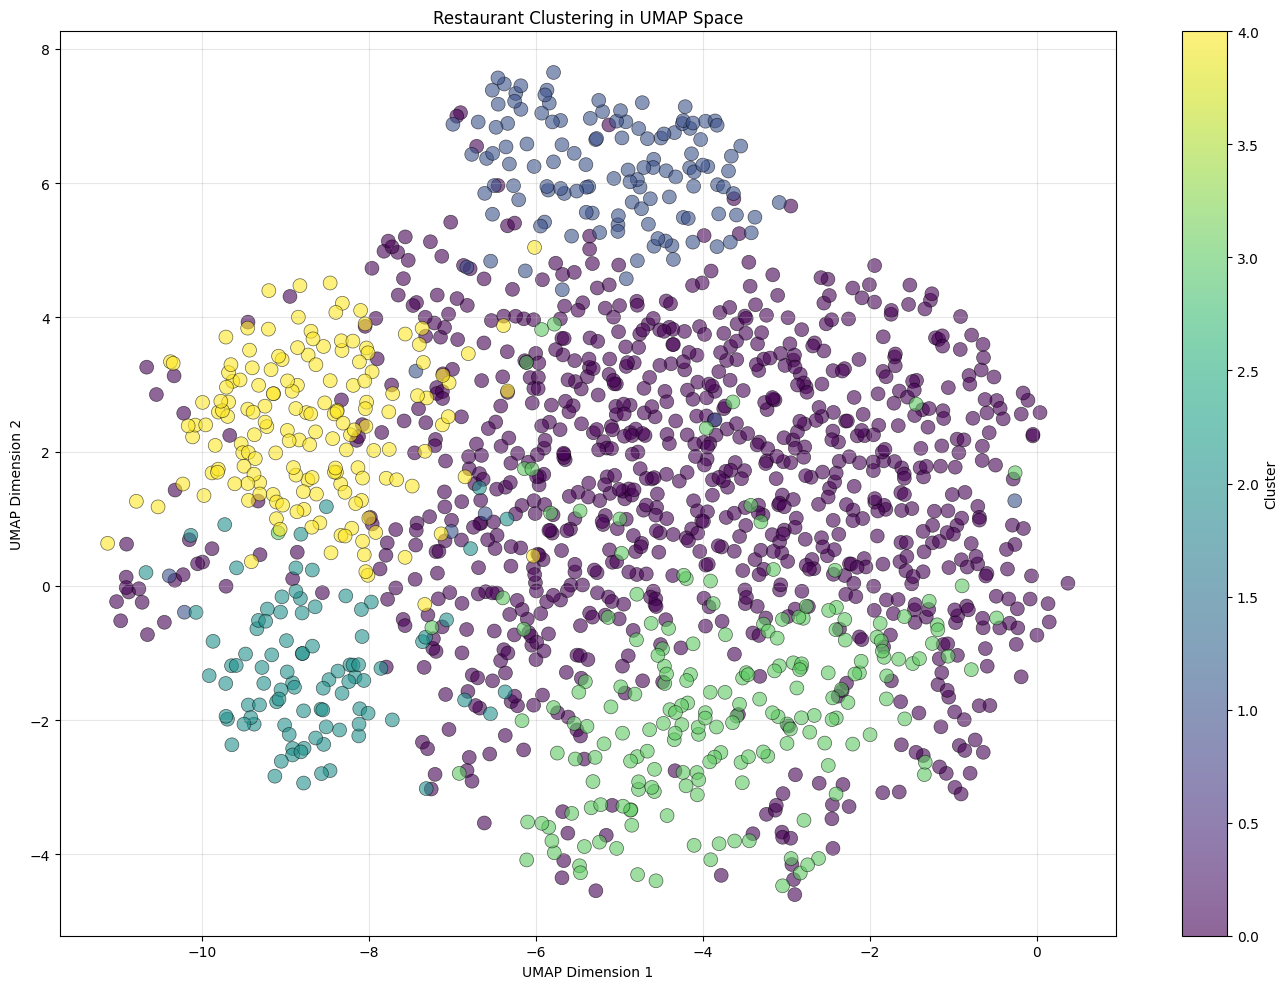

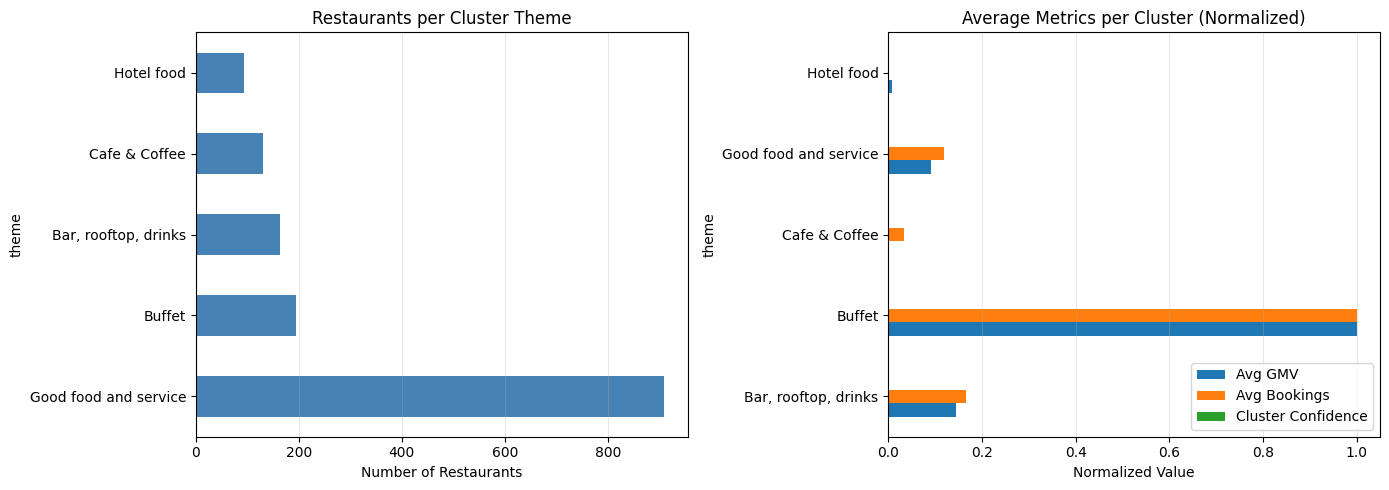


✅ VISUALIZATIONS SAVED:
  - Static UMAP plot: data_output/umap_clusters_static.png
  - Interactive UMAP plot: data_output/umap_clusters_interactive.html
  - Cluster metrics summary: data_output/cluster_metrics_summary.png


In [99]:
import matplotlib.pyplot as plt
import plotly.express as px

# VISUALIZATION 1: Matplotlib UMAP Plot (Static)
plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    clustering_results['x'], 
    clustering_results['y'], 
    c=clustering_results['cluster'], 
    cmap='viridis', 
    s=100, 
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('Restaurant Clustering in UMAP Space')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "umap_clusters_static.png", dpi=300, bbox_inches='tight')
plt.show()

# VISUALIZATION 2: Plotly Interactive UMAP Plot (Hover for Details)
fig = px.scatter(
    clustering_results,
    x='x',
    y='y',
    color='theme',
    size='review_count',
    hover_name='restaurant name',
    hover_data={
        'cluster': True,
        'theme': True,
        'review_count': True,
        'cluster_confidence': ':.2f',
        'avg_monthly_gmv': ':.0f',
        'avg_monthly_bookings': ':.0f',
        'x': False,
        'y': False
    },
    title='Interactive Restaurant Clustering (UMAP)',
    labels={
        'x': 'UMAP Dimension 1',
        'y': 'UMAP Dimension 2',
        'theme': 'Cluster Theme'
    },
    width=1000,
    height=800
)
fig.update_traces(marker=dict(line=dict(width=0.5, color='white')))
fig.write_html(OUTPUT_DIR / "umap_clusters_interactive.html")
fig.show()

# VISUALIZATION 3: Cluster Distribution Summary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cluster counts
cluster_counts = clustering_results['theme'].value_counts()
cluster_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Number of Restaurants')
axes[0].set_title('Restaurants per Cluster Theme')
axes[0].grid(axis='x', alpha=0.3)

# Plot 2: Average metrics per cluster
cluster_metrics = clustering_results.groupby('theme').agg({
    'avg_monthly_gmv': 'mean',
    'avg_monthly_bookings': 'mean',
    'cluster_confidence': 'mean'
}).reset_index()

cluster_metrics_normalized = cluster_metrics.copy()
for col in ['avg_monthly_gmv', 'avg_monthly_bookings', 'cluster_confidence']:
    cluster_metrics_normalized[col] = (cluster_metrics_normalized[col] - cluster_metrics_normalized[col].min()) / (cluster_metrics_normalized[col].max() - cluster_metrics_normalized[col].min())

cluster_metrics_normalized.set_index('theme')[['avg_monthly_gmv', 'avg_monthly_bookings', 'cluster_confidence']].plot(
    kind='barh', 
    ax=axes[1], 
    color=['#1f77b4', '#ff7f0e', '#2ca02c']
)
axes[1].set_xlabel('Normalized Value')
axes[1].set_title('Average Metrics per Cluster (Normalized)')
axes[1].legend(['Avg GMV', 'Avg Bookings', 'Cluster Confidence'], loc='lower right')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cluster_metrics_summary.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ VISUALIZATIONS SAVED:")
print(f"  - Static UMAP plot: {OUTPUT_DIR / 'umap_clusters_static.png'}")
print(f"  - Interactive UMAP plot: {OUTPUT_DIR / 'umap_clusters_interactive.html'}")
print(f"  - Cluster metrics summary: {OUTPUT_DIR / 'cluster_metrics_summary.png'}")
